## 数据准备--计算所有优化后结构CA原子的RMSD和Rg

In [ ]:
import os
import json
import numpy as np
from Bio.PDB import PDBParser, Superimposer, Selection
from Bio.PDB.PDBIO import PDBIO

def calculate_rmsd(target_pdb, reference_pdb):
    parser = PDBParser()
    ref_structure = parser.get_structure("reference", reference_pdb)
    target_structure = parser.get_structure("target", target_pdb)

    ref_atoms = []
    for ref_model in ref_structure:
        for ref_chain in ref_model:
            for ref_res in ref_chain:
                if ref_res.has_id("CA"):
                    ref_atoms.append(ref_res["CA"])

    target_atoms = []
    for target_model in target_structure:
        for target_chain in target_model:
            for target_res in target_chain:
                if target_res.has_id("CA"):
                    target_atoms.append(target_res["CA"])

    if len(ref_atoms) != len(target_atoms):
        raise ValueError("两个PDB文件中的CA原子数量不一致")
    
    super_imposer = Superimposer()
    super_imposer.set_atoms(ref_atoms, target_atoms)
    rmsd = super_imposer.rms
    
    return rmsd

def calculate_rg(pdb_file):
    parser = PDBParser()
    structure = parser.get_structure("protein", pdb_file)
    
    atoms = []
    for model in structure:
        for chain in model:
            for residue in chain:
                if residue.has_id("CA"):
                    atoms.append(residue["CA"].get_coord())
    
    if not atoms:
        raise ValueError("No CA atoms")

    coords = np.array(atoms)
    centroid = coords.mean(axis=0)
    squared_dist = np.sum((coords - centroid)**2, axis=1)
    rg = np.sqrt(np.mean(squared_dist))
    
    return rg

def merge_json_files(json_files, output_file):
    merged_data = []
    
    for json_file in json_files:
        with open(json_file, 'r') as f:
            data = json.load(f)
            merged_data.extend(data)
    
    with open(output_file, 'w') as f:
        json.dump(merged_data, f, indent=4)
    
    return merged_data

def process_pdb_files_and_save_results():
    pdb_dir = "results/cluster_opt"
    ref_pdb = "./common/pdbs/2jof_ref.pdb"
    
    json_files = [
        "results/json/u2f_grad_distance.json",
        "results/json/u2f_reverse_grad_distance.json"
    ]
    
    merged_json = "results/json/combin_grad_distance.json"
    output_file = "results/sample_analysis.txt"

    merged_data = merge_json_files(json_files, merged_json)

    data_dict = {}
    for entry in merged_data:
        step = entry["step"]
        data_dict[step] = entry
    
    results = []
    
    for step in range(0,700):
        for direction in range(1, 9):

            pdb_file = os.path.join(pdb_dir, f"{step}_pdb", f"opt_{direction}.pdb")

            if not os.path.exists(pdb_file):
                continue
            try:
                rmsd = calculate_rmsd(pdb_file, ref_pdb)
                rg = calculate_rg(pdb_file)

                if step in data_dict and str(direction) in data_dict[step]:
                    energy = data_dict[step][str(direction)]["Opt_Energy"]
                    cvs_grad = data_dict[step][str(direction)]["CVs_grad"]
                else:
                    energy = np.nan
                    cvs_grad = np.nan

                results.append([step, direction, rmsd, rg, energy, cvs_grad])
                
            except Exception as e:
                print(f"Error in step={step}, direction={direction}: {str(e)}")
                continue

    print(f"Saving results to file: {output_file}...")
    with open(output_file, 'w') as f:
        f.write("step\tdirection\tRMSD(A)\tRg(A)\tEnergy\tCVs_grad\n")

        for row in results:
            line = "\t".join(map(str, row)) + "\n"
            f.write(line)
    
    print("Complete !")

if __name__ == "__main__":
    process_pdb_files_and_save_results()

# Fig. 1 -- 单次采样的最优势能-梯度路径

-25404.930447832645
60788.841848408265


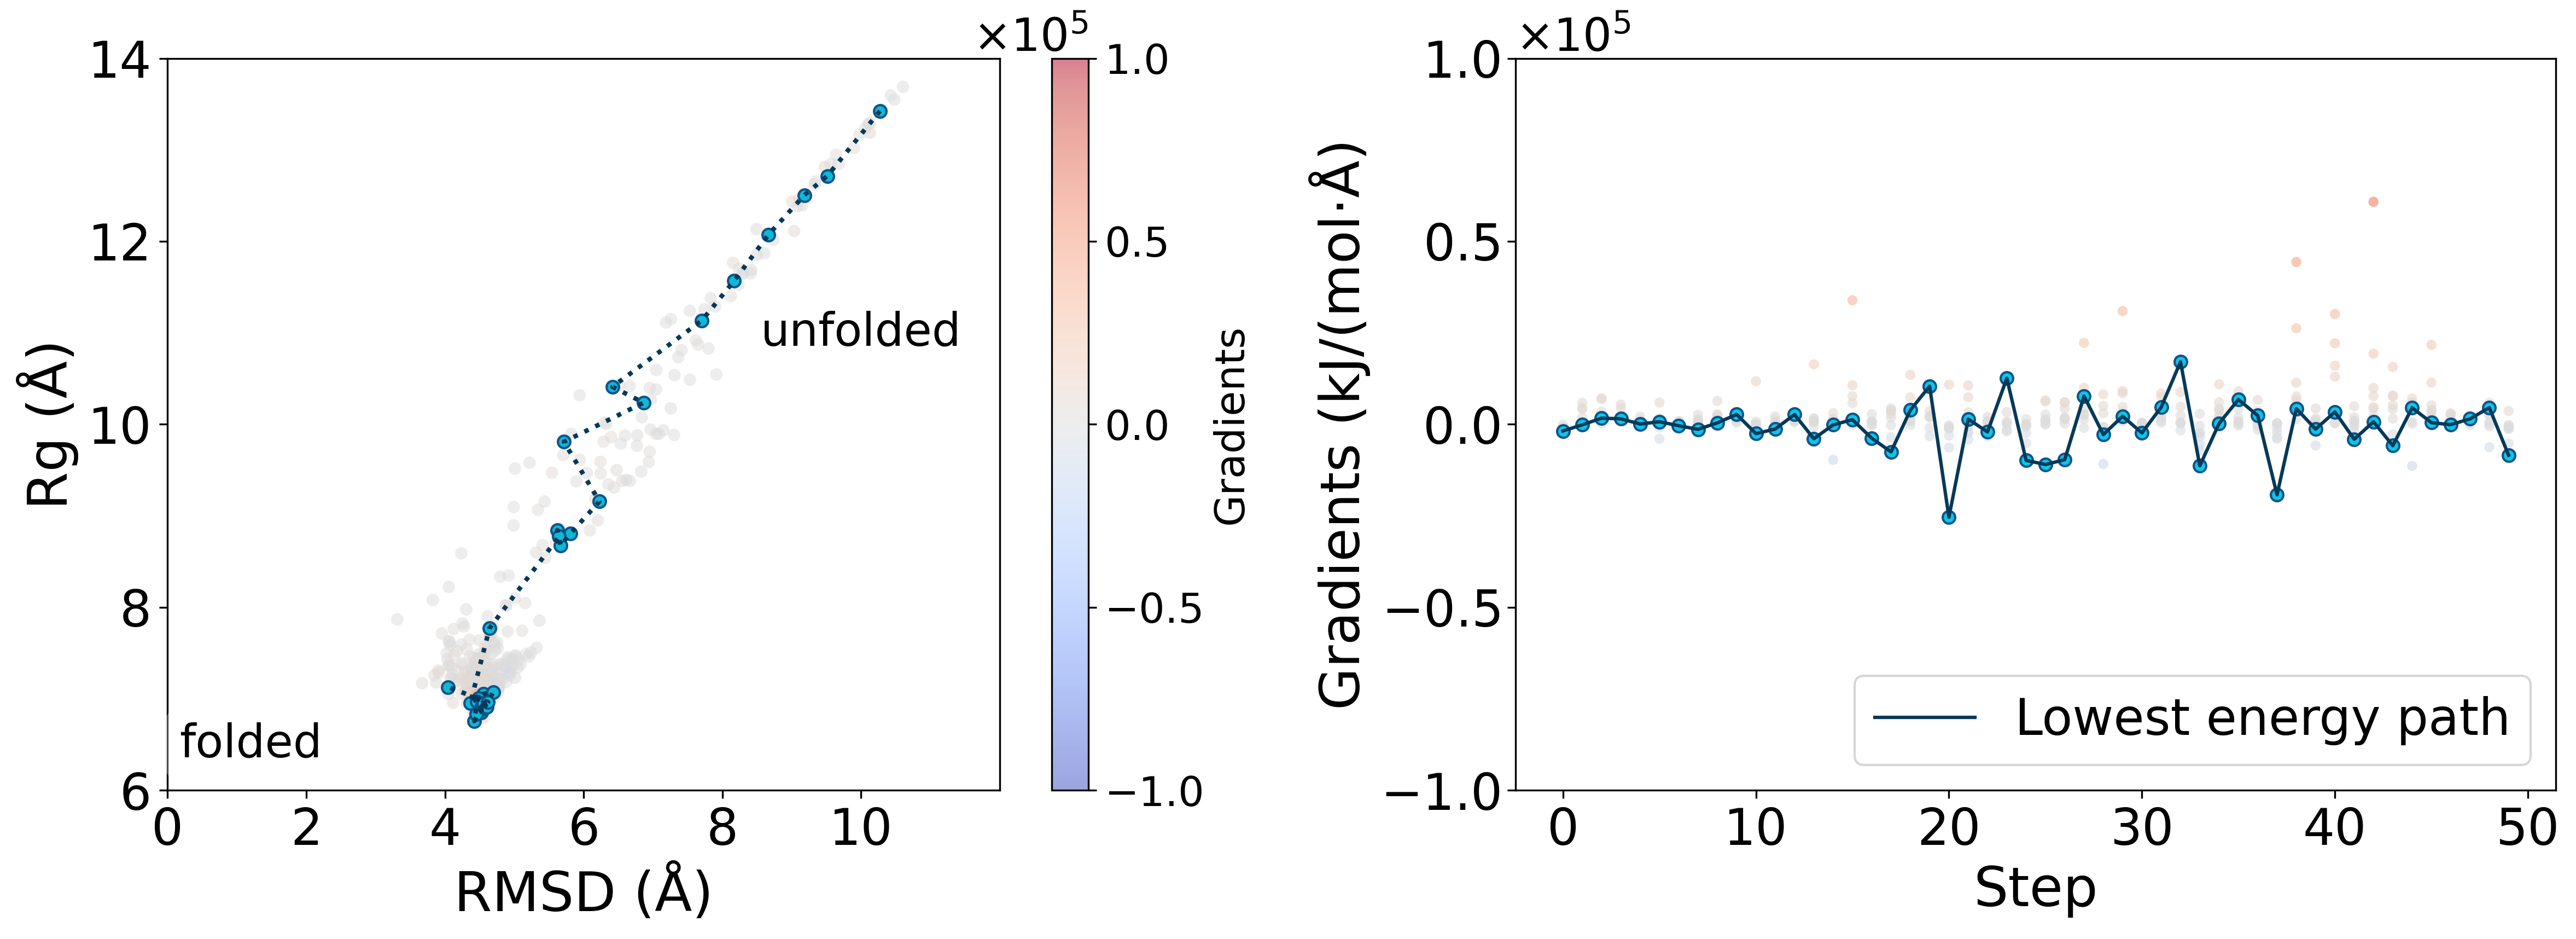

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from matplotlib.collections import LineCollection
from matplotlib.ticker import ScalarFormatter, FuncFormatter

# 设置全局字体大小
plt.rcParams.update({
    'font.size': 16,          # 全局字体大小
    'axes.titlesize': 16,     # 标题字体大小
    'axes.labelsize': 18,     # 坐标轴标签字体大小
    'xtick.labelsize': 16,    # x轴刻度字体大小
    'ytick.labelsize': 16,    # y轴刻度字体大小
    'legend.fontsize': 14     # 图例字体大小
})

# 读取保存的txt文件
data = np.loadtxt('results/sample_analysis.txt', skiprows=1)  # 跳过表头

# 读取JSON文件
with open('results/json/u2f_favorable_transition.json', 'r') as f:
    best_data = json.load(f)

# 创建2×1的子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

# ================== 左图: RMSD vs Rg 散点图 ==================
# 提取step=0到49的数据
mask = (data[:, 0] >= 0) & (data[:, 0] <= 49)
filtered_data = data[mask]

# 提取数据
steps = filtered_data[:, 0]
directions = filtered_data[:, 1]
rmsd = filtered_data[:, 2]
rg = filtered_data[:, 3]
energies = filtered_data[:, 4]
cvs_grads = filtered_data[:, 5]

clipped_grads = np.clip(cvs_grads, -100000, 100000)
norm = plt.Normalize(vmin=-100000, vmax=100000)

# 绘制散点图，用CVs_grad作为颜色映射3
sc = ax1.scatter(rmsd, rg, c=clipped_grads, s=30, alpha=0.5, edgecolors="none", cmap='coolwarm', norm = norm)
cbar = plt.colorbar(sc, ax=ax1, label='Gradients')

# 确保colorbar使用科学计数法
cbar.formatter = ScalarFormatter(useMathText=True)
cbar.formatter.set_powerlimits((0, 0))
cbar.update_ticks()
cbar.ax.tick_params(labelsize=18)  # colorbar刻度字体大小
cbar.set_ticks([-100000, -50000, 0, 50000, 100000])
cbar.ax.yaxis.get_offset_text().set_fontsize(20)  # 科学计数法字体大小

# 提取最优路径的点
best_points = []
for entry in best_data:
    if 0 <= entry['step'] <= 49:
        step = entry['step']
        best_dir = int(entry['best_direction'])

        # 在txt数据中查找对应的点
        point_mask = (steps == step) & (directions == best_dir)
        if np.any(point_mask):
            best_point = filtered_data[point_mask][0]
            best_points.append(best_point)

best_points = np.array(best_points)

# 绘制最优路径
if len(best_points) > 0:
    line_segments = np.column_stack([best_points[:, 2][0:30], best_points[:, 3][0:30]])
    lc = LineCollection([line_segments], colors="#063959", linestyle=':', linewidth=2)
    ax1.add_collection(lc)

    # 高亮最优散点边缘
    ax1.scatter(best_points[:, 2][0:30], best_points[:, 3][0:30], color="#0EB8D6", s=30, edgecolors="#0F5489", linewidths=1)

ax1.text(10, 11, 'unfolded', fontsize=20, ha='center', va='center', 
         bbox=dict(facecolor='white', alpha=0.3, edgecolor='none', boxstyle='round'))
ax1.text(1.2, 6.5, 'folded', fontsize=20, ha='center', va='center', 
         bbox=dict(facecolor='white', alpha=0.3, edgecolor='none', boxstyle='round'))
    
# 调整坐标轴范围
ax1.set_xlim(0, 12)
ax1.set_xticks([0,2,4,6,8,10])
ax1.set_ylim(6, 14)
ax1.set_yticks([6,8,10,12,14])
ax1.set_xlabel('RMSD (Å)', fontsize = 24)
ax1.set_ylabel('Rg (Å)', fontsize = 24)
ax1.tick_params(axis='both', which='major', labelsize=22)

# ================== 右图: CVs_grad vs Step ==================
# 使用与左图相同的颜色映射和归一化范围
norm = plt.Normalize(vmin=-100000, vmax=100000)
print(min(cvs_grads))
print(max(cvs_grads))
cmap = plt.get_cmap('coolwarm')

# 绘制所有step的CVs_grad (使用与左图相同的颜色映射)
ax2.scatter(steps, cvs_grads, c=cvs_grads, s=20, alpha=0.6, edgecolors='none', cmap='coolwarm', norm=norm)

# 绘制最优路径的CVs_grad
if len(best_points) > 0:
    # 连接最优CVs_grad的线
    ax2.plot(best_points[:, 0], best_points[:, 5], color="#063959", linewidth=1.5, label='Lowest energy path')
    
    # 标记最优点
    ax2.scatter(best_points[:, 0], best_points[:, 5], color="#0AC7E8", s=30, edgecolors="#0F5489")

# 设置科学计数法
ax2.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax2.yaxis.major.formatter._useMathText = True
ax2.set_ylim(-100000,100000)
ax2.set_yticks([-100000, -50000, 0, 50000, 100000])
ax2.set_xlabel('Step', fontsize = 24)
ax2.set_ylabel('Gradients (kJ/(mol·Å)', fontsize = 24)
ax2.legend(fontsize = 22, loc = 'lower right')
ax2.tick_params(axis='both', which='major', labelsize=22)
ax2.yaxis.offsetText.set_fontsize(20)  # 科学计数法字体大小

plt.tight_layout()
os.makedirs('figures', exist_ok=True)
# 保存为TIFF格式
plt.savefig('figures/f1-u2f-path-grad-stepsize.tiff', dpi=300, bbox_inches='tight', format='tiff')
plt.show()

## Fig.2 -- CVs二维空间中绘制12条路径，从unfolded到folded用同一种颜色的6种渐变，从folded到unfolded用另一种颜色的6种渐变。

In [3]:
## 先合并得到完整的最优路径文件，然后从里面获取step和best direction
import json
import os

# 定义要合并的JSON文件列表
json_files = [
    'results/json/u2f_favorable_transition.json',
    'results/json/u2f_reverse_favorable_transition.json'
] 

# 创建空列表存储合并后的数据
merged_data = []

# 逐个读取并合并JSON文件
for file_path in json_files:
    if os.path.exists(file_path):  # 检查文件是否存在
        with open(file_path, 'r') as f:
            data = json.load(f)
            if isinstance(data, list):  # 确保是列表格式
                merged_data.extend(data)
            else:
                print(f"警告: {file_path} 不是列表格式，已跳过")
    else:
        print(f"警告: 文件 {file_path} 不存在，已跳过")

# 保存合并后的数据
output_path = 'results/json/combin_favorable_transition.json'
os.makedirs(os.path.dirname(output_path), exist_ok=True)  # 确保目录存在

with open(output_path, 'w') as f:
    json.dump(merged_data, f, indent=4)  # indent=4 使输出格式化更美观

print(f"成功合并 {len(merged_data)} 条数据到 {output_path}")

成功合并 700 条数据到 results/json/combin_favorable_transition.json


In [4]:
import json
import numpy as np

# 读取合并后的JSON文件
with open('results/json/combin_favorable_transition.json', 'r') as f:
    best_path_data = json.load(f)

# 读取样本分析数据
sample_data = np.loadtxt('results/sample_analysis.txt', skiprows=1)  # 跳过表头

# 准备输出数据
output_data = []

for entry in best_path_data:
    step = entry['step']
    best_dir = int(entry['best_direction'])
    
    # 在样本数据中查找匹配的记录
    mask = (sample_data[:, 0] == step) & (sample_data[:, 1] == best_dir)
    if np.any(mask):
        matched_row = sample_data[mask][0]
        rmsd = matched_row[2]
        rg = matched_row[3]
        energy = matched_row[4]
        
        output_data.append([step, best_dir, rmsd, rg, energy])
    else:
        print(f"警告: 未找到step={step}, direction={best_dir}的匹配数据")

# 转换为numpy数组便于处理
output_array = np.array(output_data)

# 按step排序
output_array = output_array[output_array[:, 0].argsort()]

# 保存结果
output_path = 'results/favorable_pathways.txt'
header = "step\tbest_direction\tRMSD\tRg\tEnergy"
np.savetxt(output_path, output_array, fmt='%.6f', delimiter='\t', header=header, comments='')

print(f"成功保存 {len(output_array)} 条数据到 {output_path}")

成功保存 700 条数据到 results/favorable_pathways.txt


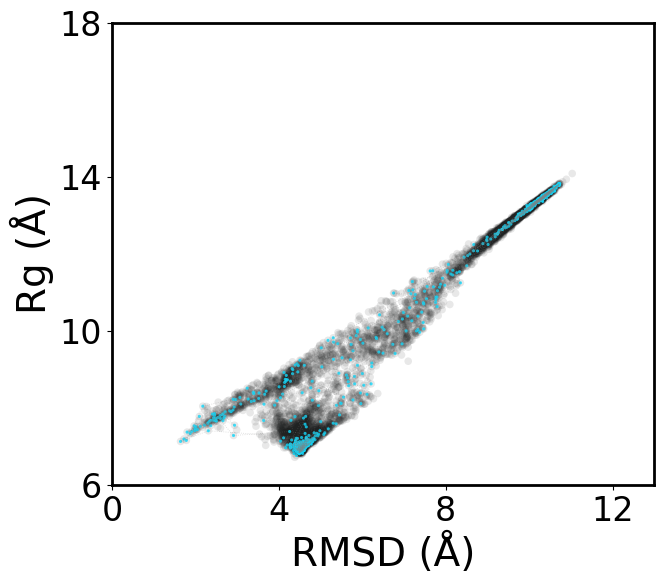

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.interpolate import UnivariateSpline, Akima1DInterpolator
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d
from loess.loess_1d import loess_1d
import os


# 读取数据
data = np.loadtxt('results/favorable_pathways.txt', skiprows=1)  # 跳过表头

# 筛选 step=0-599 的数据
data = data[(data[:, 0] >= 0) & (data[:, 0] <= 699)]

# 读取样本分析数据并提取RMSD和Rg
sample_data = np.loadtxt('results/sample_analysis.txt', skiprows=1)  # 跳过表头
sample_rmsd = sample_data[:, 2]  # RMSD列
sample_rg = sample_data[:, 3]    # Rg列

# 定义路径分组
path_groups = {
    'unfolded_to_folded': [(0, 49), (50, 99), (100, 149), (150, 199), (200, 249), (250, 299), (300, 349)],
    'folded_to_unfolded': [(350, 399), (400, 449), (450, 499), (500, 549), (550, 599),(600, 649), (650, 699)]
}

# 创建颜色渐变
def create_color_gradient(base_color, n_colors):
    base_rgb = mcolors.to_rgb(base_color)
    return [mcolors.to_hex([base_rgb[0], base_rgb[1], base_rgb[2], alpha]) 
            for alpha in np.linspace(0.6, 1, n_colors)]

color1_gradient = create_color_gradient("#0EDBFF", 7)  # 蓝色渐变
# color2_gradient = create_color_gradient("#900700", 7)  # 橙色渐变
color2_gradient = create_color_gradient("#0EDBFF", 7)  # 蓝色渐变

line_gradient = create_color_gradient("gray", 7)  # 橙色渐变

fig, ax = plt.subplots(figsize=(7, 6))

# 添加样本分析数据的灰色散点（湿润溶解效果）
ax.scatter(sample_rmsd, sample_rg, color="#202222", s=30, alpha=0.1, edgecolors='none', label='_nolegend_')

# ================== 左图: 12 条路径的散点-连线图 ==================
for i, (start, end) in enumerate(path_groups['unfolded_to_folded']):
    mask = (data[:, 0] >= start) & (data[:, 0] <= end)
    path_data = data[mask]
    color = color1_gradient[i]
    color_line = line_gradient[i]
    ax.plot(path_data[:, 2], path_data[:, 3], color=color_line, linewidth=0.6, alpha=0.3, ls=':')
    ax.scatter(path_data[:, 2], path_data[:, 3], color=color, s=5, edgecolors='none', alpha=0.8)

for i, (start, end) in enumerate(path_groups['folded_to_unfolded']):
    mask = (data[:, 0] >= start) & (data[:, 0] <= end)
    path_data = data[mask]
    color = color2_gradient[i]
    color_line = line_gradient[i]
    ax.plot(path_data[:, 2], path_data[:, 3], color=color_line, linewidth=0.6, alpha=0.3, ls=':')
    ax.scatter(path_data[:, 2], path_data[:, 3], color=color, s=5, edgecolors='none', alpha=0.8)

ax.set_xlim(0,13)
ax.set_xticks([0,4,8,12])
ax.set_ylim(6,18)
ax.set_yticks([6,10,14,18])

ax.set_xlabel('RMSD (Å)', fontsize=28)
ax.set_ylabel('Rg (Å)', fontsize=28)
ax.tick_params(axis='both', which='major', labelsize=24)

for spine in ax.spines.values():
    spine.set_linewidth(2)

os.makedirs('figures', exist_ok=True)
plt.savefig('figures/f2-cvs-space.tiff', format='tiff', dpi=300, bbox_inches='tight')
plt.show()

## 后面的代码暂时不分析

## 绘制路径

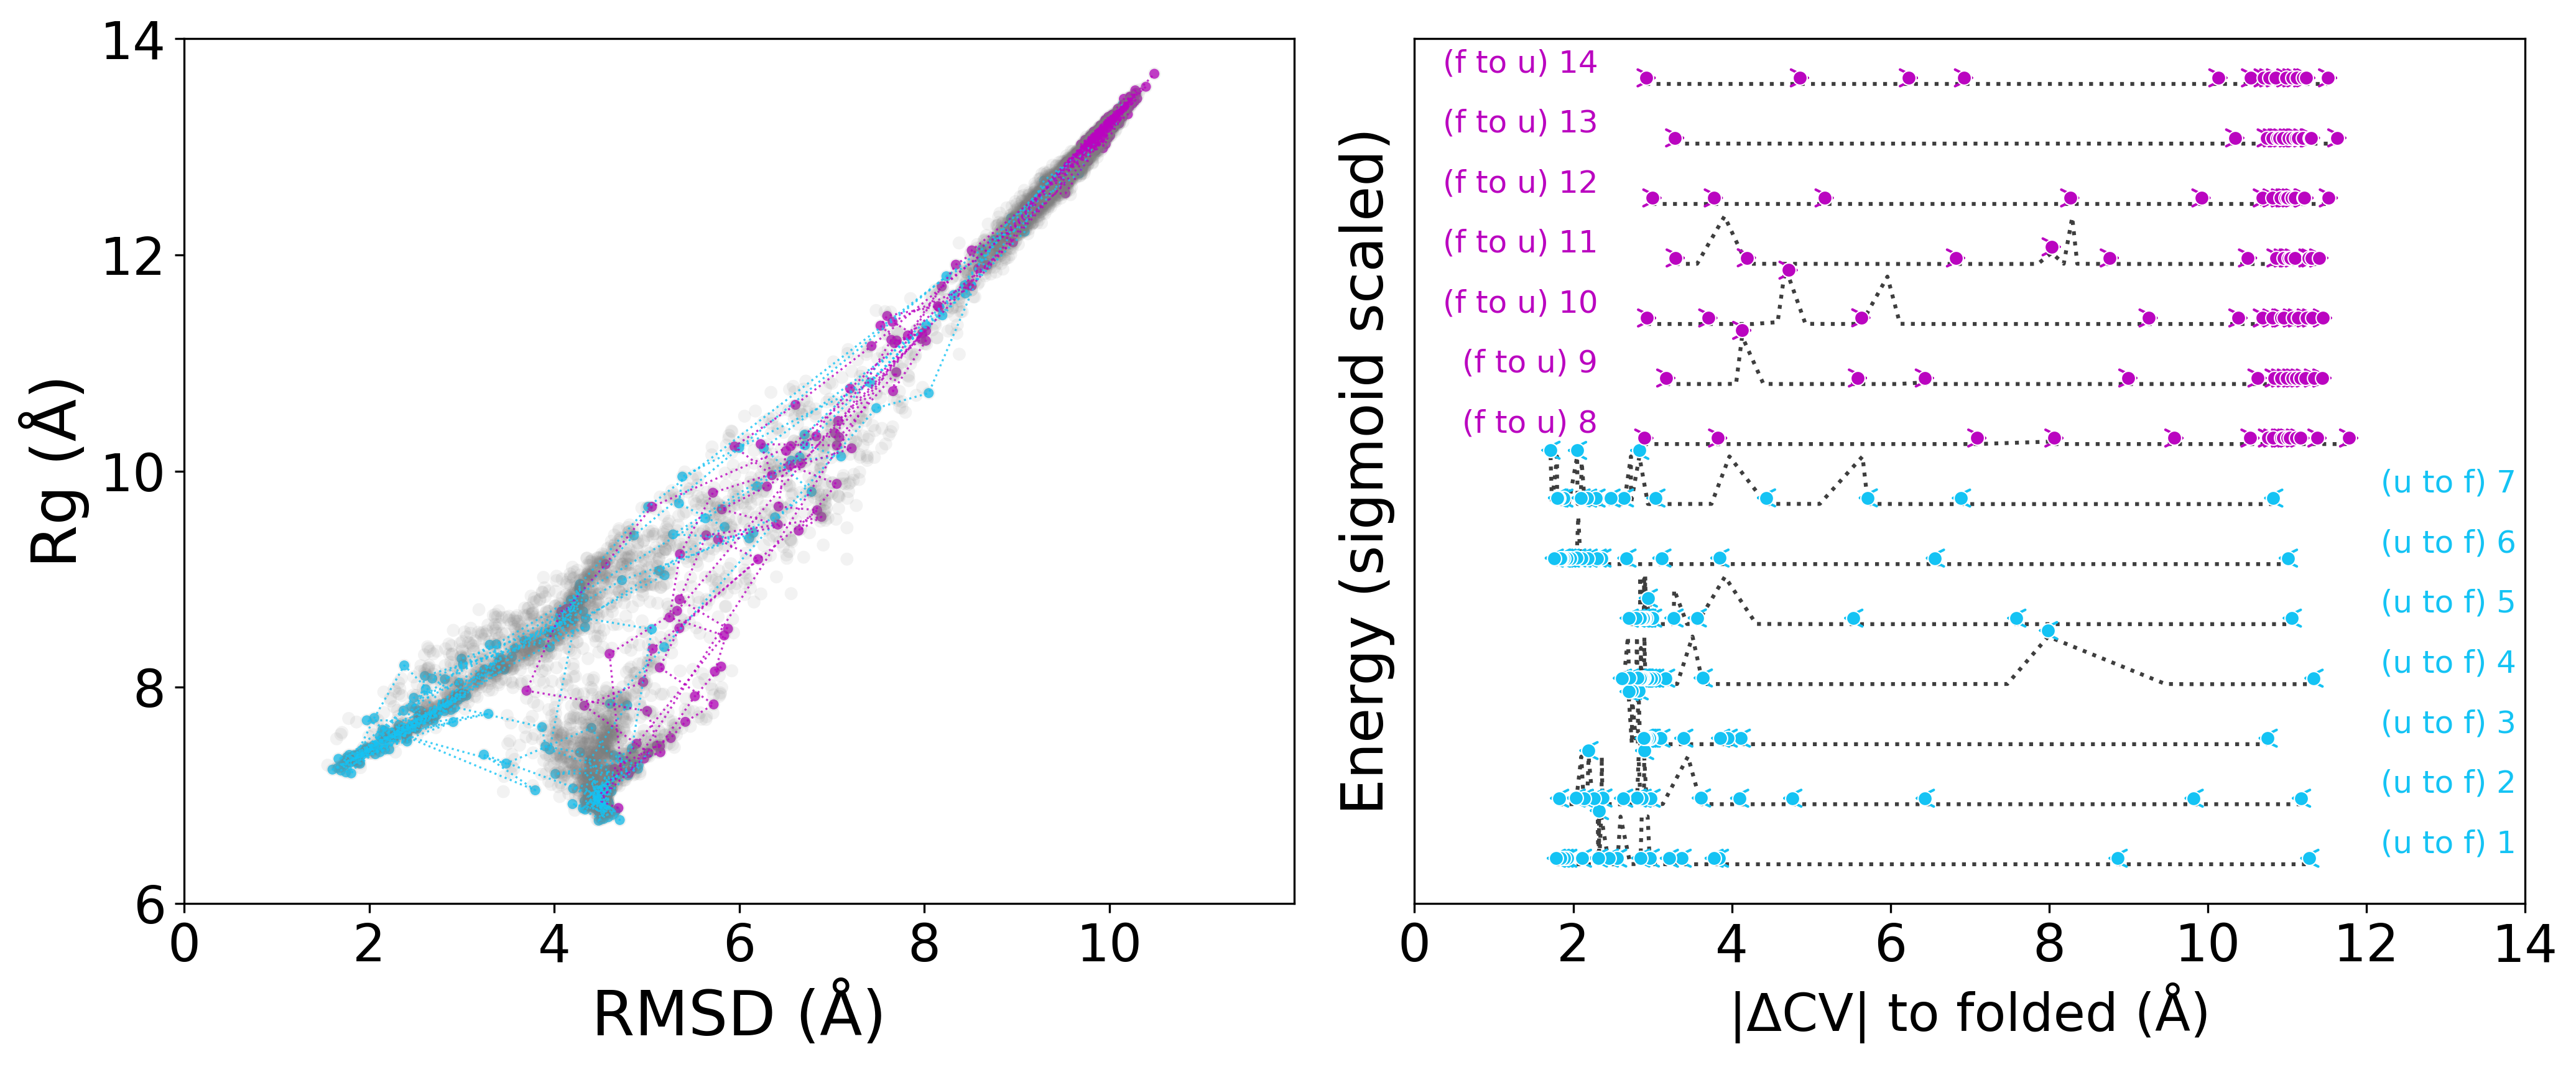

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.interpolate import UnivariateSpline, Akima1DInterpolator
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d
from loess.loess_1d import loess_1d
import os

# ================== 配置 ==================
USE_SIGMOID = True   # 使用 sigmoid 放缩到 [-5, 5]
VERTICAL_SPACING = 50  # 曲线之间的垂直间隔
SMOOTH_METHOD = 'gaussian'  # 可选择: 'savgol', 'gaussian', 'loess', 'akima', 'unispline'
MARKER_SPACING = 0.55  # 标记点之间的间距

# 读取数据
data = np.loadtxt('results/best_path.txt', skiprows=1)  # 跳过表头

# 筛选 step=0-599 的数据
data = data[(data[:, 0] >= 0) & (data[:, 0] <= 699)]

# 读取样本分析数据并提取RMSD和Rg
sample_data = np.loadtxt('results/sample_analysis.txt', skiprows=1)  # 跳过表头
sample_rmsd = sample_data[:, 2]  # RMSD列
sample_rg = sample_data[:, 3]    # Rg列

# 定义路径分组
path_groups = {
    'unfolded_to_folded': [(0, 49), (50, 99), (100, 149), (150, 199), (200, 249), (250, 299), (300, 349)],
    'folded_to_unfolded': [(350, 399), (400, 449), (450, 499), (500, 549), (550, 599),(600, 649), (650, 699)]
}

# 创建颜色渐变
def create_color_gradient(base_color, n_colors):
    base_rgb = mcolors.to_rgb(base_color)
    return [mcolors.to_hex([base_rgb[0], base_rgb[1], base_rgb[2], alpha]) 
            for alpha in np.linspace(0.6, 1, n_colors)]

color1_gradient = create_color_gradient("#14c3f4", 7)  # 蓝色渐变
color2_gradient = create_color_gradient("#BA04C0", 7)  # 橙色渐变

# 创建 2×1 子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=300)

# ================== 左图: 12 条路径的散点-连线图 ==================
for i, (start, end) in enumerate(path_groups['unfolded_to_folded']):
    mask = (data[:, 0] >= start) & (data[:, 0] <= end)
    path_data = data[mask]
    color = color1_gradient[i]
    ax1.plot(path_data[:, 2], path_data[:, 3], color=color, linewidth=0.8, alpha=0.8, ls=':')
    ax1.scatter(path_data[:, 2], path_data[:, 3], color=color, s=15, edgecolors='none', alpha=0.8)

for i, (start, end) in enumerate(path_groups['folded_to_unfolded']):
    mask = (data[:, 0] >= start) & (data[:, 0] <= end)
    path_data = data[mask]
    color = color2_gradient[i]
    ax1.plot(path_data[:, 2], path_data[:, 3], color=color, linewidth=0.8, alpha=0.8, ls=':')
    ax1.scatter(path_data[:, 2], path_data[:, 3], color=color, s=15, edgecolors='none', alpha=0.8)

# 添加样本分析数据的灰色散点（湿润溶解效果）
ax1.scatter(sample_rmsd, sample_rg, color='gray', s=25, alpha=0.1, edgecolors='none', label='_nolegend_')

ax1.set_xlim(0,12)
ax1.set_xticks([0,2,4,6,8,10])
ax1.set_ylim(6,14)
ax1.set_yticks([6,8, 10, 12, 14])

ax1.set_xlabel('RMSD (Å)', fontsize=24)
ax1.set_ylabel('Rg (Å)', fontsize=24)
ax1.tick_params(axis='both', which='major', labelsize=20)

# ================== 右图: Energy 随 distance 变化的曲线 ==================
# 计算 distance
distances = np.sqrt((data[:, 2] - 2)**2 + (data[:, 3] - 5.5)**2)

# sigmoid 放缩函数
def sigmoid_scale(x):
    return 40 / (1 + np.exp(-x / 20)) -20  # [-5, 5] 区间

# 不同的光滑处理方法
def smooth_curve(x, y, method=SMOOTH_METHOD):
    """应用不同的光滑处理方法"""
    if len(x) < 5:  # 数据点太少，直接返回
        return x, y
    
    if method == 'savgol':
        # Savitzky-Golay 滤波器 - 保持峰值特征
        window_length = min(11, len(x) if len(x) % 2 == 1 else len(x) - 1)
        if window_length < 3:
            return x, y
        y_smooth = savgol_filter(y, window_length=window_length, polyorder=2)
        return x, y_smooth
    
    elif method == 'gaussian':
        # 高斯滤波 - 平滑但可能过度平滑
        sigma = 0.3
        y_smooth = gaussian_filter1d(y, sigma=sigma)
        return x, y_smooth
    
    elif method == 'loess':
        # LOESS 局部回归 - 适应局部变化
        try:
            x_smooth = np.linspace(x.min(), x.max(), 100)
            loess_result = loess_1d(x, y, xnew=x_smooth, degree=1, frac=0.3)
            return x_smooth, loess_result
        except:
            return x, y
    
    elif method == 'akima':
        # Akima 插值 - 避免过冲
        try:
            akima = Akima1DInterpolator(x, y)
            x_smooth = np.linspace(x.min(), x.max(), 100)
            y_smooth = akima(x_smooth)
            return x_smooth, y_smooth
        except:
            return x, y
    
    elif method == 'unispline':
        # 单变量样条 - 可控制光滑度
        try:
            spline = UnivariateSpline(x, y, s=len(x)*0.1)  # s参数控制光滑度
            x_smooth = np.linspace(x.min(), x_max, 100)
            y_smooth = spline(x_smooth)
            return x_smooth, y_smooth
        except:
            return x, y
    
    else:
        return x, y

# ================== 绘制单条曲线函数 ==================
def plot_path(ax, path_range, color, offset_index, label_prefix, label_side, label_x_pos, path_type):
    mask = (data[:, 0] >= path_range[0]) & (data[:, 0] <= path_range[1])
    path_data = data[mask]
    path_dist = distances[mask]
    path_energy = path_data[:, 4]

    # 只保留 Energy < 0 的点
    neg_mask = path_energy < 3000
    path_dist = path_dist[neg_mask]
    path_energy = path_energy[neg_mask]

    if len(path_energy) < 3:
        return

    # 应用 sigmoid 放缩
    if USE_SIGMOID:
        path_energy = sigmoid_scale(path_energy)

    # 排序
    sort_idx = np.argsort(path_dist)
    path_dist_sorted = path_dist[sort_idx]
    path_energy_sorted = path_energy[sort_idx]

    # 应用曲线光滑处理
    x_smooth, y_smooth = smooth_curve(path_dist_sorted, path_energy_sorted, SMOOTH_METHOD)

    # 添加固定垂直偏移
    offset_energy = y_smooth + offset_index * VERTICAL_SPACING + 3

    # 绘制曲线
    ax.plot(x_smooth, offset_energy, color="#292929", linewidth=1.5, alpha=0.9, linestyle=":") #color=color

    # 在曲线上添加小圆标记
    # 选择间隔均匀的点
    num_markers = max(2, int((x_smooth.max() - x_smooth.min()) / MARKER_SPACING))
    
    if path_type == 'unfolded_to_folded':
        # unfolded to folded: 从右侧开始（从大到小）
        marker_indices = np.linspace(len(x_smooth)-1, 0, num_markers, dtype=int)
    else:
        # folded to unfolded: 从左侧开始（从小到大）
        marker_indices = np.linspace(0, len(x_smooth)-1, num_markers, dtype=int)
    
    for idx in marker_indices:
        if idx < len(x_smooth):
            x_point = x_smooth[idx]
            y_point = offset_energy[idx]
            
            # 绘制小圆
            ax.scatter(x_point, y_point + 5, color=color, s=30, edgecolors='white', linewidth=0.5, zorder=5)
            
            # 添加箭头
            arrow_length = 0.2  # 箭头长度
            if path_type == 'unfolded_to_folded':
                # 在小球左侧添加指向左侧的箭头
                # 箭头起点在x_point左侧，指向更左侧
                ax.annotate('', xy=(x_point - arrow_length, y_point + 5), 
                           xytext=(x_point, y_point + 5),  # 从左侧开始画
                           arrowprops=dict(arrowstyle='->', color=color, lw=1),
                           ha='right', va='center')
            else:  # folded_to_unfolded
                # 在小球右侧添加指向右侧的箭头
                ax.annotate('', xy=(x_point + arrow_length, y_point + 5), 
                           xytext=(x_point, y_point + 5),  # 从右侧开始画
                           arrowprops=dict(arrowstyle='->', color=color, lw=1),
                           ha='left', va='center')

    # 在固定的 x 位置添加标签（左或右对齐）
    ax.text(label_x_pos, offset_index * VERTICAL_SPACING,
            f"{label_prefix} {offset_index+1}",
            color=color, fontsize=12, va='center',
            ha='right' if label_side == 'left' else 'left')

# ================== 右图绘制所有轨迹 ==================
# 找到全局 x 范围，并扩展留出标签空间
x_min, x_max = np.min(distances), np.max(distances)

# unfolded→folded (右侧)
for i, (start, end) in enumerate(path_groups['unfolded_to_folded']):
    plot_path(ax2, (start, end), color1_gradient[i], i, '(u to f)',
              label_side='right', label_x_pos=x_max + 0.05 * (x_max - x_min) - 0.1,
              path_type='unfolded_to_folded')

# folded→unfolded (左侧)
for i, (start, end) in enumerate(path_groups['folded_to_unfolded']):
    plot_path(ax2, (start, end), color2_gradient[i], i+7, '(f to u)',
              label_side='left', label_x_pos=x_min - 0.05 * (x_max - x_min) + 1.1,
              path_type='folded_to_unfolded')

# 设置坐标范围，保证标签在图内
ax2.set_xlim(0, 14)
ax2.tick_params(axis='x', labelsize=20)


# 设置右图坐标轴
ax2.set_xlabel('|ΔCV| to folded (Å)', fontsize=20)
ax2.set_ylabel('Energy (sigmoid scaled)', fontsize=22)
ax2.yaxis.set_ticklabels([])  # 隐藏 y 轴刻度标签
ax2.tick_params(axis='y', which='both', length=0)

# 调整布局
plt.tight_layout()

# 确保输出目录存在
os.makedirs('figures', exist_ok=True)

# 保存图片为TIFF格式
plt.savefig('figures/f3-2jof-cvs-space-energy.tiff', format='tiff', dpi=300, bbox_inches='tight')

plt.show()

## 路径相似度（方向和欧几里得相似度）

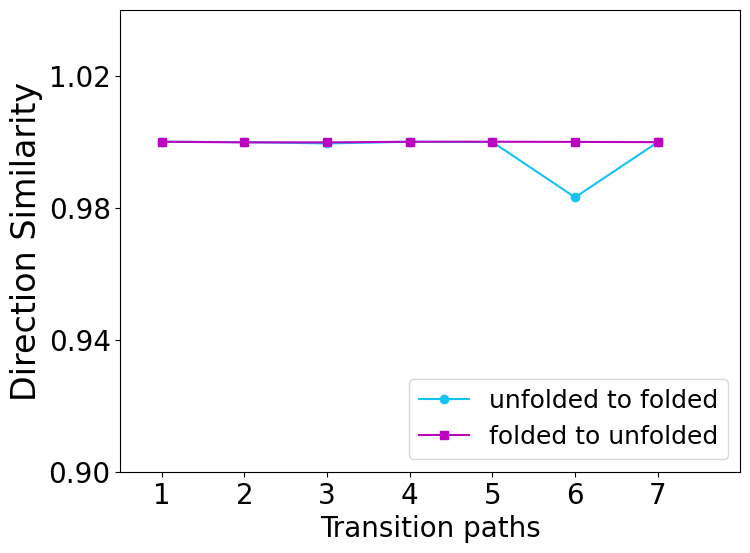

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

# 读取数据
data = np.loadtxt('results/best_path.txt', skiprows=1)  # 跳过表头

# 筛选 step=0-599 的数据
data = data[(data[:, 0] >= 0) & (data[:, 0] <= 699)]

# 读取样本分析数据并提取RMSD和Rg
sample_data = np.loadtxt('results/sample_analysis.txt', skiprows=1)  # 跳过表头
sample_rmsd = sample_data[:, 2]  # RMSD列
sample_rg = sample_data[:, 3]    # Rg列

# 定义路径分组
path_groups = {
    'unfolded_to_folded': [(0, 49), (50, 99), (100, 149), (150, 199), (200, 249), (250, 299), (300, 349)],
    'folded_to_unfolded': [(350, 399), (400, 449), (450, 499), (500, 549), (550, 599),(600, 649), (650, 699)]
}

# 创建颜色渐变
def create_color_gradient(base_color, n_colors):
    base_rgb = mcolors.to_rgb(base_color)
    return [mcolors.to_hex([base_rgb[0], base_rgb[1], base_rgb[2], alpha]) 
            for alpha in np.linspace(0.6, 1, n_colors)]

color1_gradient = create_color_gradient("#14c3f4", 7)  # 蓝色渐变
color2_gradient = create_color_gradient("#BA04C0", 7)  # 橙色渐变

# 创建 1×3 子图
fig, ax = plt.subplots(figsize=(8, 6))

# ================== 右图: 路径相似度 ==================
def compute_path_similarity(path_ranges):
    vectors = []
    for (start, end) in path_ranges:
        mask = (data[:, 0] >= start) & (data[:, 0] <= end)
        path_data = data[mask][:, 2:4]  # RMSD 和 Rg
        vec = (path_data[-1] - path_data[0])
        vectors.append(vec)
    ref_vec = vectors[0]
    sims = []
    for vec in vectors:
        if np.linalg.norm(vec) == 0 or np.linalg.norm(ref_vec) == 0:
            sims.append(0)
        else:
            sims.append(np.dot(ref_vec, vec) / (np.linalg.norm(ref_vec) * np.linalg.norm(vec)))
    return np.array(sims)

sim_unfolded = compute_path_similarity(path_groups['unfolded_to_folded'])
sim_folded = compute_path_similarity(path_groups['folded_to_unfolded'])

ax.plot(range(1,8), sim_unfolded, marker='o', color="#14c3f4", label="unfolded to folded")
ax.plot(range(1,8), sim_folded, marker='s', color="#BA04C0", label="folded to unfolded")

ax.set_xlabel("Transition paths", fontsize=20)
ax.set_ylabel("Direction Similarity", fontsize=24)
ax.set_xticks([1,2,3,4,5,6,7])
ax.set_yticks([0.90, 0.94, 0.98, 1.02])
ax.set_xlim(0.5, 8)
ax.set_ylim(0.9, 1.04)
ax.tick_params(axis='both', labelsize=20)
ax.legend(fontsize=18, loc = "lower right")


os.makedirs('figures', exist_ok=True)
plt.savefig('figures/f4-2jof-cos-similarity.tiff', format='tiff', dpi=300, bbox_inches='tight')
plt.show()


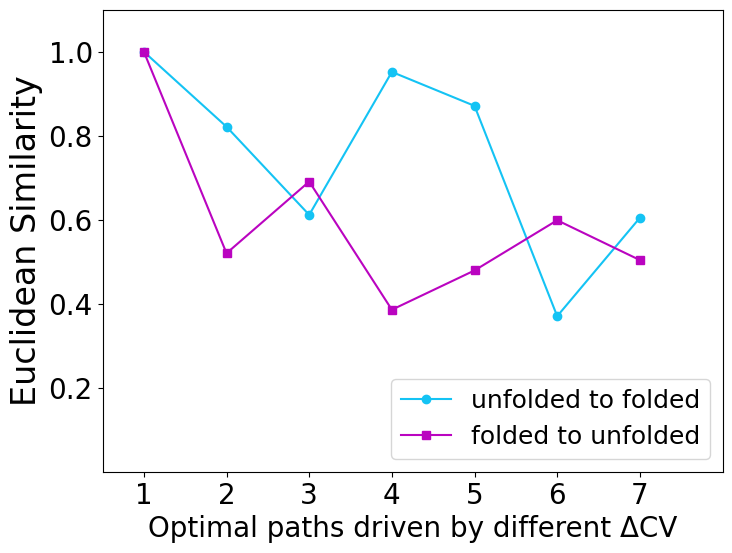

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

data = np.loadtxt('results/best_path.txt', skiprows=1)
data = data[(data[:, 0] >= 0) & (data[:, 0] <= 699)]

# 样本分析数据
sample_data = np.loadtxt('results/sample_analysis.txt', skiprows=1)
sample_rmsd = sample_data[:, 2]
sample_rg = sample_data[:, 3]

# 路径分组
path_groups = {
    'unfolded_to_folded': [(0, 49), (50, 99), (100, 149), (150, 199), (200, 249), (250, 299), (300, 349)],
    'folded_to_unfolded': [(350, 399), (400, 449), (450, 499), (500, 549), (550, 599),(600, 649), (650, 699)]
}

# 颜色渐变
def create_color_gradient(base_color, n_colors):
    base_rgb = mcolors.to_rgb(base_color)
    return [mcolors.to_hex([base_rgb[0], base_rgb[1], base_rgb[2], alpha])
            for alpha in np.linspace(0.6, 1, n_colors)]

color1_gradient = create_color_gradient("#14c3f4", 7)
color2_gradient = create_color_gradient("#BA04C0", 7)

fig, ax = plt.subplots(figsize=(8, 6))

# ================== 右图: 欧几里得相似度 ==================
def compute_path_similarity(path_ranges):
    vectors = []
    for (start, end) in path_ranges:
        mask = (data[:, 0] >= start) & (data[:, 0] <= end)
        path_data = data[mask][:, 2:4]  # RMSD & Rg
        vec = path_data[-1] - path_data[0]
        vectors.append(vec)
    ref_vec = vectors[0]
    dists = [np.linalg.norm(vec - ref_vec) for vec in vectors]
    max_d, min_d = max(dists), min(dists)
    # return dists
    # sims = [(max_d - d) / (max_d - min_d + 1e-9) for d in dists]  # 归一化相似度
    sims = [1/(d + 1) for d in dists]
    return np.array(sims)

sim_unfolded = compute_path_similarity(path_groups['unfolded_to_folded'])
sim_folded = compute_path_similarity(path_groups['folded_to_unfolded'])

ax.plot(range(1,8), sim_unfolded, marker='o', color="#14c3f4", label="unfolded to folded")
ax.plot(range(1,8), sim_folded, marker='s', color="#BA04C0", label="folded to unfolded")
ax.set_xlabel("Optimal paths driven by different ΔCV", fontsize=20)
ax.set_ylabel("Euclidean Similarity", fontsize=24)
ax.set_xticks([1,2,3,4,5,6,7])
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1])
ax.set_xlim(0.5, 8)
ax.set_ylim(0, 1.1)
ax.tick_params(axis='both', labelsize=20)
ax.legend(fontsize=18, loc = "lower right")

os.makedirs('figures', exist_ok=True)
plt.savefig('figures/f5-2jof-cvs-euclidean-similarity.tiff',
            format='tiff', dpi=300, bbox_inches='tight')
plt.show()


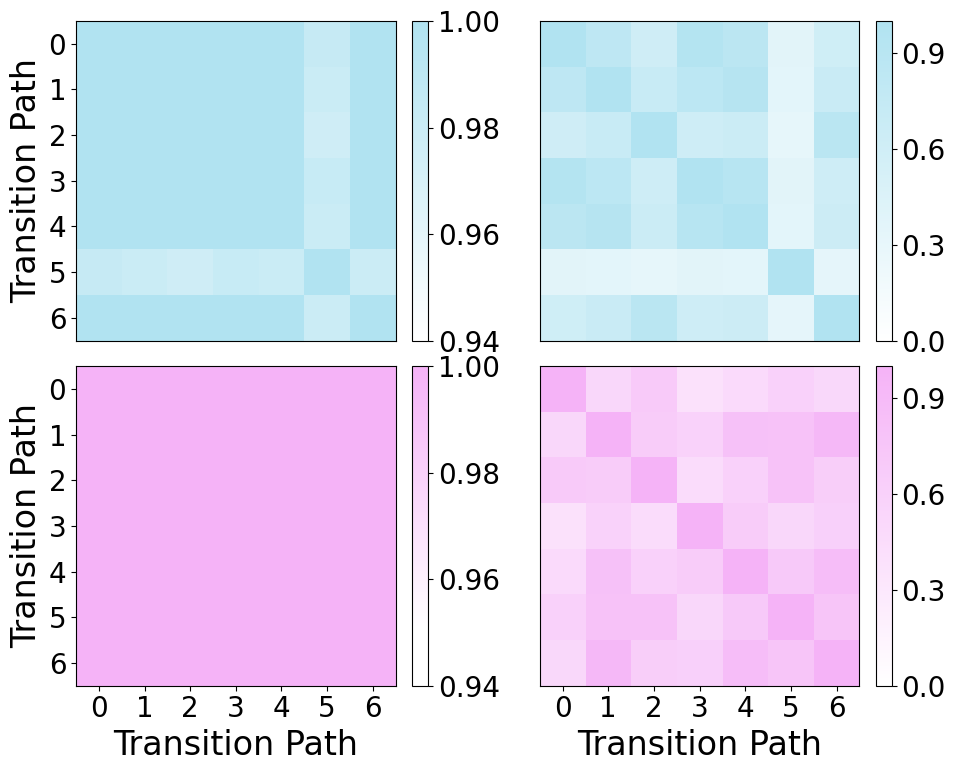

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.colors import LinearSegmentedColormap


# ========== 数据读取 ==========
data = np.loadtxt('results/best_path.txt', skiprows=1)
data = data[(data[:, 0] >= 0) & (data[:, 0] <= 699)]

# 路径定义
path_groups = {
    'unfolded_to_folded': [(0, 49), (50, 99), (100, 149), (150, 199), (200, 249), (250, 299), (300, 349)],
    'folded_to_unfolded': [(350, 399), (400, 449), (450, 499), (500, 549), (550, 599),(600, 649), (650, 699)]
}

# ========== 方向相似度矩阵 ==========
def direction_similarity_matrix(path_ranges):
    n = len(path_ranges)
    vectors = []
    for (start, end) in path_ranges:
        mask = (data[:, 0] >= start) & (data[:, 0] <= end)
        path_data = data[mask][:, 2:4]  # RMSD & Rg
        vec = path_data[-1] - path_data[0]
        vectors.append(vec)
    sims = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            v1, v2 = vectors[i], vectors[j]
            if np.linalg.norm(v1) == 0 or np.linalg.norm(v2) == 0:
                sims[i, j] = 0
            else:
                sims[i, j] = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return sims

# ========== 欧几里得相似度矩阵 ==========
def euclidean_similarity_matrix(path_ranges):
    n = len(path_ranges)
    vectors = []
    for (start, end) in path_ranges:
        mask = (data[:, 0] >= start) & (data[:, 0] <= end)
        path_data = data[mask][:, 2:4]
        vec = path_data[-1] - path_data[0]
        vectors.append(vec)
    sims = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            dist = np.linalg.norm(vectors[i] - vectors[j])
            sims[i, j] = 1 / (1 + dist)  # 距离越近相似度越高
    return sims

# ========== 计算四个6×6矩阵 ==========
dir_sim_unfolded = direction_similarity_matrix(path_groups['unfolded_to_folded'])
dir_sim_folded = direction_similarity_matrix(path_groups['folded_to_unfolded'])
euc_sim_unfolded = euclidean_similarity_matrix(path_groups['unfolded_to_folded'])
euc_sim_folded = euclidean_similarity_matrix(path_groups['folded_to_unfolded'])

# ========== 绘图 ==========
fig, axes = plt.subplots(2, 2, figsize=(10, 8))


colors_uf = ["#ffffff", "#b1e3f1"]  # 浅蓝到深蓝
custom_cmap_uf = LinearSegmentedColormap.from_list("my_blues", colors_uf)


colors_fu = ["#ffffff", "#F5B3F7"]
custom_cmap_fu = LinearSegmentedColormap.from_list("my_blues", colors_fu)


# ---- 左上：U→F 方向相似度 (蓝色)
im1 = axes[0, 0].imshow(dir_sim_unfolded, cmap=custom_cmap_uf, vmin=0.94, vmax=1)
# axes[0, 0].set_title("U→F Direction Similarity", fontsize=18)
axes[0, 0].set_xticks([])
axes[0, 0].set_yticks(range(7))
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Transition Path", fontsize=24)
axes[0, 0].tick_params(axis='both', labelsize=20)
cbar1 = fig.colorbar(im1, ax=axes[0, 0], fraction=0.046, pad=0.04)
cbar1.set_ticks([0.94, 0.96, 0.98, 1.0])
cbar1.ax.tick_params(labelsize=20)

# ---- 右上：U→F 欧几里得相似度 (蓝色)
im2 = axes[0, 1].imshow(euc_sim_unfolded, cmap=custom_cmap_uf, vmin=0, vmax=1)
# axes[0, 1].set_title("U→F Euclidean Similarity", fontsize=18)
axes[0, 1].set_xticks([])
axes[0, 1].set_yticks([])
axes[0, 1].set_xlabel("")
axes[0, 1].set_yticklabels([])
axes[0, 1].tick_params(axis='both', labelsize=20)
cbar2 = fig.colorbar(im2, ax=axes[0, 1], fraction=0.046, pad=0.04)
cbar2.set_ticks([0, 0.3, 0.6, 0.9])
cbar2.ax.tick_params(labelsize=20)

# ---- 左下：F→U 方向相似度 (紫色)
im3 = axes[1, 0].imshow(dir_sim_folded, cmap=custom_cmap_fu, vmin=0.95, vmax=1)
# axes[1, 0].set_title("F→U Direction Similarity", fontsize=18)
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_yticks(range(7))
axes[1, 0].set_xlabel("Transition Path", fontsize=24)
axes[1, 0].set_ylabel("Transition Path", fontsize=24)
axes[1, 0].tick_params(axis='both', labelsize=20)
cbar3 = fig.colorbar(im3, ax=axes[1, 0], fraction=0.046, pad=0.04)
cbar3.set_ticks([0.94, 0.96, 0.98, 1.0])
cbar3.ax.tick_params(labelsize=20)

# ---- 右下：F→U 欧几里得相似度 (紫色)
im4 = axes[1, 1].imshow(euc_sim_folded, cmap=custom_cmap_fu, vmin=0, vmax=1)
# axes[1, 1].set_title("F→U Euclidean Similarity", fontsize=18)
axes[1, 1].set_xticks(range(7))
axes[1, 1].set_yticks([])
axes[1, 1].set_xlabel("Transition Path", fontsize=24)
axes[1, 1].set_ylabel("")
axes[1, 1].set_yticklabels([])
axes[1, 1].tick_params(axis='both', labelsize=20)
cbar4 = fig.colorbar(im4, ax=axes[1, 1], fraction=0.046, pad=0.04)
cbar4.set_ticks([0, 0.3, 0.6, 0.9])
cbar4.ax.tick_params(labelsize=20)

plt.tight_layout()
plt.subplots_adjust(hspace=0.08)

# 保存
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/f6-2jof-similarity-heatmaps.tiff', format='tiff', dpi=300, bbox_inches='tight')
plt.show()


## Fig. 3 -- Energy Surface -- 2D & Representative structures

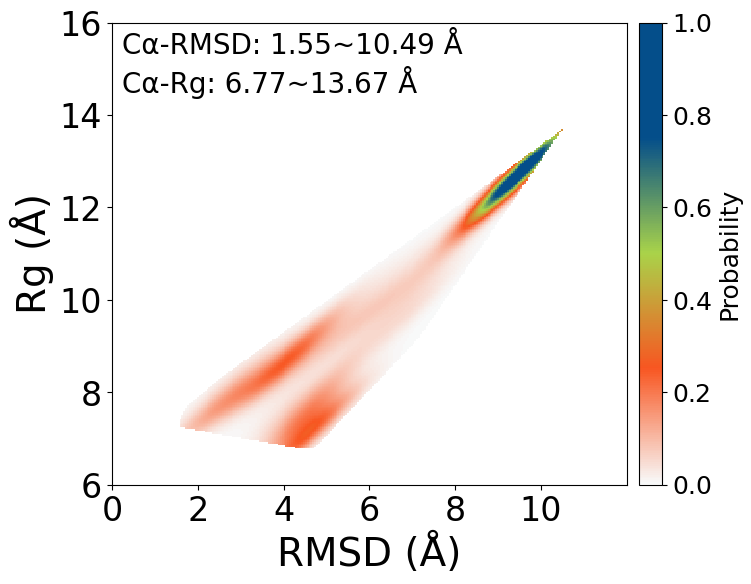

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import matplotlib.colors as mcolors
from scipy.spatial import ConvexHull
from matplotlib.path import Path
from matplotlib.ticker import ScalarFormatter, FuncFormatter

# 读取RMSD数据
# rmsd_data = np.loadtxt('results/2jof_rmsd_rg_gbmd.txt', delimiter=',', usecols=0, skiprows=1)  # 只读取第一列

# # 计算RMSD的概率密度分布
# rmsd_kde = gaussian_kde(rmsd_data, bw_method=0.4)
# rmsd_x = np.linspace(0, 8, 500)  # 使用与主图相同的x轴范围
# rmsd_density = rmsd_kde(rmsd_x)

# 读取主图数据
data = np.loadtxt('results/sample_analysis.txt', skiprows=1)  # 跳过表头
rmsd = data[:, 2]  # RMSD(A)
rg = data[:, 3]    # Rg(A)
energy = data[:, 4]  # Energy

# 过滤异常能量值
valid_mask = (energy > -100000) & (energy < np.inf)
rmsd_filtered = rmsd[valid_mask]
rg_filtered = rg[valid_mask]
energy_filtered = energy[valid_mask]

# 范围
rmsd_min, rmsd_max = rmsd_filtered.min(), rmsd_filtered.max()
rg_min, rg_max = rg_filtered.min(), rg_filtered.max()

# 创建图形
fig, ax_main = plt.subplots(figsize=(8, 6))

# 创建网格
grid_size = 200
xi = np.linspace(rmsd_min, rmsd_max, grid_size)
yi = np.linspace(rg_min, rg_max, grid_size)
xi, yi = np.meshgrid(xi, yi)

# 高斯核密度估计
coordinates = np.vstack([rmsd_filtered, rg_filtered])
kde = gaussian_kde(coordinates)

zi = kde(np.vstack([xi.flatten(), yi.flatten()]))
zi = zi.reshape(xi.shape)
zi = (zi-zi.min())/(zi.max()-zi.min())
# 数据区域凸包
points = np.column_stack([rmsd_filtered, rg_filtered])
if len(points) > 3:
    hull = ConvexHull(points)
    hull_path = Path(points[hull.vertices])
else:
    hull_path = Path(np.array([[rmsd_min, rg_min], [rmsd_max, rg_min],
                               [rmsd_max, rg_max], [rmsd_min, rg_max]]))

grid_points = np.column_stack([xi.flatten(), yi.flatten()])
inside_mask = hull_path.contains_points(grid_points).reshape(xi.shape)
zi_masked = np.where(inside_mask, zi, np.nan)

# 配色
colors = ["#F8F9F9", "#F85621", "#A9D349","#044E8A", "#044E8A"]#['white', 'cyan', 'blue', 'red']
cmap_custom = mcolors.LinearSegmentedColormap.from_list('red_blue_cyan', colors, N=256)

# 概率分布图
im = ax_main.pcolormesh(xi, yi, zi_masked, cmap=cmap_custom, shading='auto')

# 颜色栏
cbar = plt.colorbar(im, ax=ax_main, label='Probability', pad=0.02)
cbar.set_label('Probability', fontsize=18)
cbar.ax.tick_params(labelsize=18)

cbar.formatter = ScalarFormatter(useMathText=True)
cbar.formatter.set_powerlimits((0, 0))
cbar.update_ticks()
cbar.ax.tick_params(labelsize=18)  # colorbar刻度字体大小
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1]) 
cbar.ax.yaxis.get_offset_text().set_fontsize(20)  # 科学计数法字体大小

# 坐标范围
ax_main.set_xlim(0, 12)
ax_main.set_xticks([0,2, 4, 6, 8,10])
ax_main.set_ylim(6, 16)
ax_main.set_yticks([6, 8, 10, 12, 14, 16])
ax_main.tick_params(axis='both', labelsize=24)

# 坐标轴标签
ax_main.set_xlabel('RMSD (Å)', fontsize=28)
ax_main.set_ylabel('Rg (Å)', fontsize=28)

# ---------- 在主图横轴下方绘制 RMSD 分布 ----------
# 归一化到图中一小段高度（比如 5 ~ 5.2 之间）
# density_scaled = (rmsd_density / rmsd_density.max()) * 1  # 缩放到 0.2 Å 高度
# ax_main.fill_between(rmsd_x, 4, 4 + density_scaled, color="gray", alpha=0.5)
# ax_main.plot(rmsd_x, 4 + density_scaled, color="black", linewidth=1)

# 信息文字
ax_main.text(0.02, 0.98, 
             f'Cα-RMSD: {rmsd_min:.2f}~{rmsd_max:.2f} Å\nCα-Rg: {rg_min:.2f}~{rg_max:.2f} Å', #\nPoints = {len(rmsd_filtered)},\nSystem: 2jof (Implicit solvation)
             transform=ax_main.transAxes, fontsize=20, verticalalignment='top',
             bbox=dict(edgecolor='none', facecolor='white', alpha=0.8))

# ax_main.text(0.2, 0.08, f'RMSD$_{{\mathrm{{ISMD, 100ns}}}}$=1.06 Å',
#              transform=ax_main.transAxes, fontsize=22, verticalalignment='top',
#              bbox=dict(edgecolor='none', facecolor='white', alpha=0.2)) #Rg = 5.58 Å

ax_main.set_facecolor('white')
plt.savefig('figures/f7-2jof-2d_probability_density_with_rmsd_curve.tiff', dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_1740389/2864550758.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  best_path_data = pd.read_csv('results/best_path.txt', delim_whitespace=True)


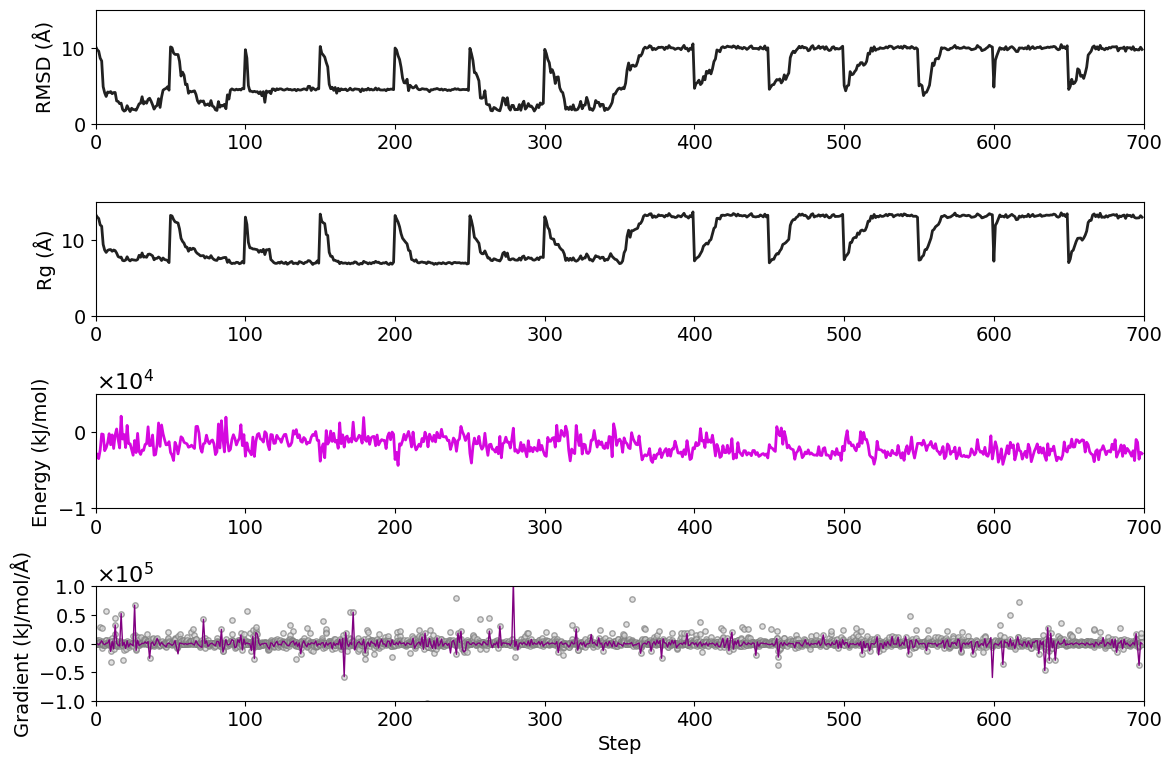

In [5]:
import json
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from matplotlib.ticker import ScalarFormatter

# 确保figures目录存在
os.makedirs('figures', exist_ok=True)

# 读取best_path文件
best_path_data = pd.read_csv('results/best_path.txt', delim_whitespace=True)
# 只取step 0-599的数据
best_path_data = best_path_data[(best_path_data['step'] >= 0) & (best_path_data['step'] <= 699)]

# 提取数据
steps = best_path_data['step'].values
rmsd = best_path_data['RMSD'].values
rg = best_path_data['Rg'].values
energies = best_path_data['Energy'].values
best_directions = best_path_data['best_direction'].values

# 读取grad_distance_all.json文件
with open('results/json/grad_distance_all.json', 'r') as f:
    grad_data = json.load(f)

# 提取每个step的最佳direction的CVs_grad和所有direction的CVs_grad
best_cvs_grads = []
all_cvs_grads = {}

for step in steps:
    step_int = int(step)
    # 找到对应的step数据
    step_data = None
    for item in grad_data:
        if item['step'] == step_int:
            step_data = item
            break
    
    if step_data:
        # 获取最佳direction的CVs_grad（如果存在，否则NaN）
        best_dir = int(best_directions[steps == step][0])
        if str(best_dir) in step_data:
            best_cvs_grad = step_data[str(best_dir)]['CVs_grad']
        else:
            best_cvs_grad = np.nan
        best_cvs_grads.append(best_cvs_grad)
        
        # 获取所有direction的CVs_grad，缺失的填np.nan
        all_cvs_grads[step_int] = [
            step_data[str(i)]['CVs_grad'] if str(i) in step_data else np.nan
            for i in range(1, 8)
        ]
    else:
        best_cvs_grads.append(np.nan)
        all_cvs_grads[step_int] = [np.nan] * 8

best_cvs_grads = np.array(best_cvs_grads)

# 创建科学计数法格式化器
sci_formatter = ScalarFormatter(useMathText=True)
sci_formatter.set_powerlimits((-3, 4))

# 创建4个独立的图形
fig, axes = plt.subplots(4, 1, figsize=(12, 8))

# 图1: RMSD
axes[0].plot(steps, rmsd, color="#212121", linewidth=2)
axes[0].set_ylabel('RMSD (Å)', fontsize=14)
axes[0].set_xlim(0, 700)
axes[0].set_ylim(0, 15)  # 设置RMSD范围为1-10 Å
axes[0].tick_params(axis='both', which='major', labelsize=14)

# 图2: Rg
axes[1].plot(steps, rg, color='#212121', linewidth=2)
axes[1].set_ylabel('Rg (Å)', fontsize=14)
axes[1].set_xlim(0, 700)
axes[1].set_ylim(0, 15)  # 设置Rg范围为5-10 Å
axes[1].tick_params(axis='both', which='major', labelsize=14)

# 图3: Energy
axes[2].plot(steps, energies, color='#D508DF', linewidth=2)
axes[2].set_ylabel('Energy (kJ/mol)', fontsize=14)
axes[2].set_xlim(0, 700)
axes[2].set_ylim(-10000, 5000)  # 设置Energy范围为-3500~20000 kJ/mol
axes[2].yaxis.set_major_formatter(sci_formatter)  # 使用科学计数法
axes[2].tick_params(axis='both', which='major', labelsize=14)

# 图4: CVs_grad
axes[3].plot(steps, best_cvs_grads, color='purple', linewidth=1, label='Optimal Direction')
# 添加所有direction的散点
for step in steps:
    step_int = int(step)
    if step_int in all_cvs_grads:
        x_scatter = np.full(7, step)
        y_scatter = all_cvs_grads[step_int]
        axes[3].scatter(x_scatter, y_scatter, color='lightgray', s=15, alpha=0.7, 
                       edgecolors='gray', label='Directions' if step == steps[0] else "")

axes[3].set_ylabel('Gradient (kJ/mol/Å)', fontsize=14)
axes[3].set_xlabel('Step', fontsize=14)
axes[3].set_xlim(0, 700)
axes[3].set_ylim(-100000, 100000)  # 设置CVs gradient范围为-10000~15000 kJ/mol/Å
axes[3].set_yticks([-100000,-50000,0,50000,100000])
axes[3].yaxis.set_major_formatter(sci_formatter)  # 使用科学计数法
axes[3].tick_params(axis='both', which='major', labelsize=14)
# axes[3].legend(loc = "lower right", fontsize = 12)

plt.tight_layout()
plt.savefig('figures/f8-2jof_trajectory_analysis.tiff', dpi=300, format='tiff', bbox_inches='tight')
plt.show()

# 分别保存单个图形
# 图1: RMSD
plt.figure(figsize=(12, 4))
plt.plot(steps, rmsd, color='blue', linewidth=2)
plt.ylabel('RMSD (Å)', fontsize=14)
plt.xlabel('Step', fontsize=14)
plt.xlim(0, 700)
plt.ylim(0, 15)
plt.tight_layout()
plt.savefig('figures/f9-2jof_rmsd_vs_step.tiff', dpi=300, format='tiff', bbox_inches='tight')
plt.close()

# 图2: Rg
plt.figure(figsize=(12, 4))
plt.plot(steps, rg, color='green', linewidth=2)
plt.ylabel('Rg (Å)', fontsize=14)
plt.xlabel('Step', fontsize=14)
plt.xlim(0, 700)
plt.ylim(0, 15)
plt.tight_layout()
plt.savefig('figures/f10-2jof_rg_vs_step.tiff', dpi=300, format='tiff', bbox_inches='tight')
plt.close()

# 图3: Energy
plt.figure(figsize=(12, 4))
plt.plot(steps, energies, color="#D508DF", linewidth=2)
plt.ylabel('Energy (kJ/mol)', fontsize=14)
plt.xlabel('Step', fontsize=14)
plt.xlim(0, 700)
plt.ylim(-10000, 5000)
plt.gca().yaxis.set_major_formatter(sci_formatter)  # 使用科学计数法
plt.tight_layout()
plt.savefig('figures/f11-2jof_energy_vs_step.tiff', dpi=300, format='tiff', bbox_inches='tight')
plt.close()

# 图4: CVs_grad
plt.figure(figsize=(12, 4))
plt.plot(steps, best_cvs_grads, color='purple', linewidth=2, label='Best Direction')
# 添加所有direction的散点
for step in steps:
    step_int = int(step)
    if step_int in all_cvs_grads:
        x_scatter = np.full(7, step)
        y_scatter = all_cvs_grads[step_int]
        plt.scatter(x_scatter, y_scatter, color='lightgray', s=20, alpha=0.7, 
                   edgecolors='gray', label='All Directions' if step == steps[0] else "")

plt.ylabel('Gradient (kJ/mol/Å)', fontsize=14)
plt.xlabel('Step', fontsize=14)
plt.xlim(0, 700)
plt.ylim(-100000, 100000)
plt.yticks([-100000,-50000,0,50000,100000])
plt.gca().yaxis.set_major_formatter(sci_formatter)  # 使用科学计数法
# plt.legend(loc = "lower right")
plt.tight_layout()
plt.savefig('figures/f12-2jof_cvs_grad_vs_step.tiff', dpi=300, format='tiff', bbox_inches='tight')
plt.close()

In [2]:
import os
from PIL import Image

# 设置目录
figures_dir = "figures"

# 支持的 TIFF 扩展名（不区分大小写）
tiff_extensions = {'.tiff', '.tif'}

# 遍历目录中的所有文件
for filename in os.listdir(figures_dir):
    name, ext = os.path.splitext(filename)
    if ext.lower() in tiff_extensions:
        input_path = os.path.join(figures_dir, filename)
        
        # 统一输出为 .tif（小写）
        output_filename = name + ".tif"
        output_path = os.path.join(figures_dir, output_filename)

        try:
            # 打开图像
            with Image.open(input_path) as img:
                # 保留原始图像的所有信息（包括 mode、dpi 等）
                # 使用 LZW 无损压缩以减小文件体积，不损失精度
                save_kwargs = {
                    'format': 'TIFF',
                    'compression': 'tiff_lzw'
                }

                # 如果原图包含 DPI 信息，保留它
                if 'dpi' in img.info:
                    save_kwargs['dpi'] = img.info['dpi']

                # 如果是多页 TIFF（如动画或多帧），需要特殊处理（此处假设单页）
                # matplotlib 生成的通常是单页，所以直接保存即可
                img.save(output_path, **save_kwargs)
            
            print(f"✅ 已压缩并保存: {filename} -> {output_filename}")

        except Exception as e:
            print(f"❌ 处理 {filename} 时出错: {e}")

✅ 已压缩并保存: f12-2jof_cvs_grad_vs_step.tiff -> f12-2jof_cvs_grad_vs_step.tif
✅ 已压缩并保存: f7-2jof-2d_probability_density_with_rmsd_curve.tif -> f7-2jof-2d_probability_density_with_rmsd_curve.tif
✅ 已压缩并保存: f1-2jof-u2f-path-grad-stepsize.tif -> f1-2jof-u2f-path-grad-stepsize.tif
✅ 已压缩并保存: f2-2jof-cvs-space.tif -> f2-2jof-cvs-space.tif
✅ 已压缩并保存: f10-2jof_rg_vs_step.tif -> f10-2jof_rg_vs_step.tif
✅ 已压缩并保存: f5-2jof-cvs-euclidean-similarity.tif -> f5-2jof-cvs-euclidean-similarity.tif
✅ 已压缩并保存: f11-2jof_energy_vs_step.tif -> f11-2jof_energy_vs_step.tif
✅ 已压缩并保存: f11-2jof_energy_vs_step.tiff -> f11-2jof_energy_vs_step.tif
✅ 已压缩并保存: f2-2jof-cvs-space.tiff -> f2-2jof-cvs-space.tif
✅ 已压缩并保存: f5-2jof-cvs-euclidean-similarity.tiff -> f5-2jof-cvs-euclidean-similarity.tif
✅ 已压缩并保存: f6-2jof-similarity-heatmaps.tif -> f6-2jof-similarity-heatmaps.tif
✅ 已压缩并保存: f3-2jof-cvs-space-energy.tif -> f3-2jof-cvs-space-energy.tif
✅ 已压缩并保存: f4-2jof-cos-similarity.tif -> f4-2jof-cos-similarity.tif
✅ 已压缩并保存: f12-2jof_cvs_